In [61]:
import gzip
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.metrics.cluster import v_measure_score, contingency_matrix

from pysrc.papers.utils import vectorize_corpus, build_corpus, vectorize, lda_topics, \
                               explain_lda_topics, compute_tfidf, tokenize
from utils.analysis import align_clusterings_for_sklearn
from utils.io import load_analyzer, load_clustering, get_review_pmids
from utils.preprocessing import preprocess_clustering

In [5]:
PMID = 28003656

In [6]:
analyzer = load_analyzer(PMID)
clustering = load_clustering(PMID)

In [95]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

full_corpus = []

for pmid in pmids:
    af = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
    a = reload_exported_analyzer(af)
    corpus = build_corpus(a.df)
    vectorizer = CountVectorizer(
        min_df=0.05,
        ngram_range=(1, 1),
        max_features=None,
        tokenizer=lambda t: tokenize(t)
    )
    counts = vectorizer.fit_transform(corpus)
    total_counts = counts.sum(axis=0)
    dictionary = vectorizer.get_feature_names()
    
    words = []
    for i, word in enumerate(dictionary):
        words.extend([word] * total_counts[0, i])
    
    print(pmid, len(words))
    full_corpus.append(' '.join(words))

26580716 44803
26580717 49385
26656254 38582
26667849 39043
26675821 40267
26678314 43176
26688349 44334
26688350 43148
27677859 39023
27677860 39191
27834397 41746
27834398 38862
27890914 43263
27904142 39561
27916977 36449
28003656 39299
28792006 39428
28852220 42040
28853444 49160
28920587 42923
29147025 42643
29170536 39315
29213134 38033
29321682 41692
30108335 38132
30390028 41139
30459365 38285
30467385 39101
30578414 41675
30644449 43230
30679807 38269
30842595 46059
31686003 43869
31806885 44857
31836872 41595
31937935 44354
32005979 44126
32020081 37094
32042144 40748
32699292 42167


In [8]:
ground_truth = preprocess_clustering(clustering, 2, 
                                     include_box_sections=False,
                                     uniqueness_method='unique_only')

In [66]:
from pysrc.papers.utils import preprocess_text, STOP_WORDS_SET

ground_truth_pmids = sorted(ground_truth.keys())
ground_truth_col = pd.DataFrame(ground_truth.items(), columns=['id', 'ground_truth'])
df = analyzer.df[analyzer.df.id.isin(ground_truth_pmids)].merge(ground_truth_col, on='id')
titles = [preprocess_text(s) for s in list(df['title'])]
abstracts = [preprocess_text(s) for s in list(df['abstract'])]

In [53]:
df

,id,title,abstract,year,type,keywords,mesh,doi,aux,authors,...,2016,2017,2018,2019,2020,2021,total,comp,pagerank,ground_truth
0,25673851,Differential magnetic resonance neurofeedback ...,Previous advances in magnetic resonance imagin...,2015,Article,"default mode network,imagery,neurofeedback,rea...","Adult,Brain Mapping,Cerebral Cortex physiology...",10.1523/JNEUROSCI.3098-14.2015,"{'authors': [{'name': 'Harmelech T', 'affiliat...","Harmelech T, Friedman D, Malach R",...,3,8,0,3,4,0,18,0,0.001659,4
1,20538065,Slow EEG pattern predicts reduced intrinsic fu...,The last two decades have witnessed great prog...,2010,Article,,"Adolescent,Adult,Biological Clocks physiology,...",10.1016/j.neuroimage.2010.06.002,"{'authors': [{'name': 'Hlinka J', 'affiliation...","Hlinka J, Alexakis C, Diukova A, Liddle PF, Au...",...,1,3,5,1,2,0,29,0,0.001681,5
2,25566028,Tuning pathological brain oscillations with ne...,Neurofeedback (NFB) is emerging as a promising...,2014,Article,"brain computer interface (BCI),brain disorders...",,10.3389/fnhum.2014.01008,"{'authors': [{'name': 'Ros T', 'affiliation': ...","Ros T, J Baars B, Lanius RA, Vuilleumier P",...,2,6,2,4,5,0,22,0,0.001587,1
3,23719815,"The day-after effect: long term, Hebbian-like ...","During rest, the cerebral cortex displays rich...",2013,Article,,"Adult,Behavior physiology,Brain Mapping,Cerebr...",10.1523/JNEUROSCI.5911-12.2013,"{'authors': [{'name': 'Harmelech T', 'affiliat...","Harmelech T, Preminger S, Wertman E, Malach R",...,9,5,6,4,3,0,39,0,0.001735,1
4,23253623,High-performance neuroprosthetic control by an...,Paralysis or amputation of an arm results in t...,2013,ClinicalTrial,,"Arm,Artificial Limbs,Brain-Computer Interfaces...",10.1016/S0140-6736(12)61816-9,"{'authors': [{'name': 'Collinger JL', 'affilia...","Collinger JL, Wodlinger B, Downey JE, Wang W, ...",...,51,43,57,44,39,0,371,3,0.002782,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,15978025,Neuronal mechanisms underlying control of a br...,Brain-computer interfaces (BCIs) enable humans...,2005,Article,,"Adult,Biofeedback Psychology physiology,Brain ...",10.1111/j.1460-9568.2005.04092.x,"{'authors': [{'name': 'Hinterberger T', 'affil...","Hinterberger T, Veit R, Wilhelm B, Weiskopf N,...",...,1,3,2,2,2,0,24,0,0.001885,4
121,11449024,The clinical role of computerized EEG in the e...,Quantitative EEG (QEEG) can play an important ...,2001,Review,,"Adolescent,Attention Deficit Disorder with Hyp...",10.1176/jnp.13.2.171,"{'authors': [{'name': 'Chabot RJ', 'affiliatio...","Chabot RJ, di Michele F, Prichep L, John ER",...,0,3,6,0,1,0,17,0,0.001918,5
122,24151462,Learning to modulate one's own brain activity:...,"Using neurofeedback (NF), individuals can lear...",2013,Article,"EEG,gamma,implicit learning,mental strategies,...",,10.3389/fnhum.2013.00695,"{'authors': [{'name': 'Kober SE', 'affiliation...","Kober SE, Witte M, Ninaus M, Neuper C, Wood G",...,1,7,9,3,7,0,36,0,0.001732,3
123,25519874,Competition between items in working memory le...,Switching attention from one thought to the ne...,2014,Article,,"Adolescent,Adult,Attention physiology,Cues,Fem...",10.1038/ncomms6768,"{'authors': [{'name': 'Lewis-Peacock JA', 'aff...","Lewis-Peacock JA, Norman KA",...,8,9,1,7,4,0,29,0,0.001587,0


In [23]:
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer

In [96]:
def my_tokenize(text):
    tokenized = word_tokenize(text)
    return [token for token in tokenized if token not in STOP_WORDS_SET and not token.isdigit()]

In [124]:
from scipy.sparse import hstack

title_vectorizer = CountVectorizer(
    tokenizer=my_tokenize,
    ngram_range=(1, 1),
    min_df=0.02
)
abstract_vectorizer = CountVectorizer(
    tokenizer=my_tokenize,
    ngram_range=(1, 1),
    min_df=0.02
)
X_titles = title_vectorizer.fit_transform(titles).toarray()
X_abstracts = abstract_vectorizer.fit_transform(abstracts).toarray()
print(X_titles.shape, X_abstracts.shape)
X_full = np.concatenate((X_titles, X_abstracts), axis=1)
print(X_full.shape)
y = df['ground_truth']

(125, 100) (125, 1115)
(125, 1215)


In [125]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

clf = RandomForestClassifier(n_estimators=20, max_depth=6, random_state=0).fit(X_abstracts, y)
labels_train = clf.predict(X_abstracts)
print('Train:', accuracy_score(y, labels_train))

Train: 0.944


In [126]:
# feature_names = [f'title_{w}' for w in title_vectorizer.get_feature_names()] + \
#                 [f'abstract_{w}' for w in abstract_vectorizer.get_feature_names()]
feature_names = abstract_vectorizer.get_feature_names()
importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_],
             axis=0)
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")

word_importances = {}
for f in range(X_abstracts.shape[1]):
    print("%d. feature %d - %s - (%f)" % (f + 1, indices[f], feature_names[indices[f]], importances[indices[f]]))
    word_importances[feature_names[indices[f]]] = importances[indices[f]]
    
# Plot the impurity-based feature importances of the forest
# plt.figure()
# plt.title("Feature importances")
# plt.bar(range(X_abstracts.shape[1]), importances[indices],
#         color="r", yerr=std[indices], align="center")
# plt.xticks(range(X_abstracts.shape[1]), [feature_names[x] for x in indices], rotation=90)
# plt.xlim([-1, X_abstracts.shape[1]])
# plt.show()

Feature ranking:
1. feature 618 - motor - (0.042317)
2. feature 442 - hyperactivity - (0.035311)
3. feature 142 - children - (0.034229)
4. feature 235 - deficit - (0.020996)
5. feature 706 - participants - (0.020176)
6. feature 978 - stroke - (0.019417)
7. feature 234 - default - (0.017671)
8. feature 30 - adhd - (0.016288)
9. feature 713 - patients - (0.014909)
10. feature 32 - adolescents - (0.014481)
11. feature 277 - disorder - (0.013742)
12. feature 299 - effects - (0.011790)
13. feature 880 - resting - (0.011684)
14. feature 649 - neurons - (0.011068)
15. feature 951 - slow - (0.010465)
16. feature 1 - ability - (0.010152)
17. feature 1094 - volitional - (0.010097)
18. feature 873 - resonance - (0.010068)
19. feature 37 - age - (0.009950)
20. feature 984 - studies - (0.009775)
21. feature 564 - magnetic - (0.009444)
22. feature 589 - mental - (0.008980)
23. feature 848 - regulation - (0.008681)
24. feature 400 - frequency - (0.008269)
25. feature 898 - role - (0.008108)
26. featu

1087. feature 690 - overview - (0.000000)
1088. feature 731 - phenomenon - (0.000000)
1089. feature 730 - phase - (0.000000)
1090. feature 729 - pharmacological - (0.000000)
1091. feature 728 - personal - (0.000000)
1092. feature 727 - person - (0.000000)
1093. feature 726 - persist - (0.000000)
1094. feature 724 - period - (0.000000)
1095. feature 720 - perform - (0.000000)
1096. feature 718 - per - (0.000000)
1097. feature 716 - peak - (0.000000)
1098. feature 714 - pattern - (0.000000)
1099. feature 712 - pathways - (0.000000)
1100. feature 711 - passive - (0.000000)
1101. feature 710 - parts - (0.000000)
1102. feature 709 - particularly - (0.000000)
1103. feature 708 - particular - (0.000000)
1104. feature 705 - participant - (0.000000)
1105. feature 704 - partial - (0.000000)
1106. feature 701 - parents - (0.000000)
1107. feature 700 - parent - (0.000000)
1108. feature 699 - parameters - (0.000000)
1109. feature 698 - paralyzed - (0.000000)
1110. feature 697 - paralysis - (0.00000

In [35]:
vectorizer.get_feature_names()

['activation',
 'activity',
 'adhd',
 'analysis',
 'attention',
 'attention deficit',
 'attention deficit hyperactivity',
 'attention deficit hyperactivity disorder',
 'based',
 'bold',
 'brain',
 'brain networks',
 'changes',
 'children',
 'clinical',
 'cognitive',
 'computer',
 'connectivity',
 'control',
 'controlled',
 'cortex',
 'cortical',
 'default',
 'default mode',
 'deficit',
 'deficit hyperactivity',
 'deficit hyperactivity disorder',
 'dependent',
 'disorder',
 'dopamine',
 'eeg',
 'effects',
 'emotion',
 'evidence',
 'feedback',
 'fmri',
 'function',
 'functional',
 'functional connectivity',
 'human',
 'human brain',
 'humans',
 'hyperactivity',
 'hyperactivity disorder',
 'imaging',
 'interface',
 'intrinsic',
 'learning',
 'magnetic',
 'mechanisms',
 'memory',
 'meta',
 'meta analysis',
 'mode',
 'modulation',
 'motor',
 'network',
 'networks',
 'neural',
 'neurofeedback',
 'neurofeedback training',
 'neuronal',
 'neurons',
 'oscillations',
 'performance',
 'plasticity'

In [115]:
def vectorize_corpus(df, max_features, n_gram, min_df, max_df):
    corpus = build_corpus(df)
    vectorizer = CountVectorizer(
        min_df=min_df,
        max_df=max_df if len(df) > 1 else 1.0,  # For tests
        ngram_range=(1, n_gram),
        max_features=max_features,
        tokenizer=lambda t: tokenize(t)
    )
    counts = vectorizer.fit_transform(corpus)
    return vectorizer.get_feature_names(), counts

In [116]:
dictionary, counts = vectorize_corpus(df, max_features=10000, n_gram=1, min_df=0.01, max_df=0.5)

In [117]:
for w in dictionary:
    print(word_importances.get(w, 0), w)

0.010151615725260313 ability
0.0 able
0.0 abnormal
0.0 absence
0.0 academic
0.0 acc
0.0 account
0 accumbens
0.0 accuracy
0 accurate
0 achievable
0.0 acquisition
0.0 action
0.002015145825926841 activation
0.00557480912086422 active
0.0 actual
0 adaptation
0 adaptive
0.0029010708616019915 addition
0.0 additional
0 adequate
0.016287718056895915 adhd
0 administration
0.0 adolescent
0.002548081678904658 adult
0 advance
0.0 adverse
0 affect
0.009950384241943066 age
0 agency
0 aid
0.0 aim
0 algorithm
0.0 algorithms
0.0 alpha
0 alteration
0.0 alternative
0 amount
0.0022441250815030504 amplitude
0.0015613868796114513 amygdala
0.0 analysis
0 analytic
0.0 anatomical
0 anatomy
0 animal
0 anisotropy
0.0 anterior
0.0 application
0.004787014670358804 approach
0.0 appropriate
0.0 area
0.003512374951314957 arm
0.0 arousal
0.0 array
0 artefact
0.0 article
0 artifact
0 artificial
0 aspect
0.0 assessment
0.003644464358901124 association
0 assumption
0 atomoxetine
0 attempt
0.007738680869489281 attention
0

0 voxel
0 wakefulness
0 wave
0.0 way
0.004490650816984312 week
0.0 whereas
0.0 white
0.0 whole
0 wide
0.0013116972189435316 work
0.0030760790575140888 year
0 young


In [117]:
useful_indices = []
for i, word in enumerate(vectorizer.get_feature_names()):
    if word in useful_words_list:
        useful_indices.append(i)

In [119]:
useful_counts = counts[:, useful_indices]

In [120]:
useful_counts.shape

(500, 200)

In [136]:
for n_topics in range(3, 50):   
    topics, lda = lda_topics(useful_counts, n_topics=n_topics)
    partition = {k: v for k, v in zip(list(analyzer.df.id.values), list(topics.argmax(axis=1)))}
    labels_true, labels_pred = align_clusterings_for_sklearn(partition, ground_truth)
    n_clusters = len(set(labels_pred))
    
    print(n_topics, v_measure_score(labels_true, labels_pred) - 0.01 * n_clusters)

3 0.012294018113161095
4 0.09760440677989496
5 0.18560007493963326
6 0.17169045676746647
7 0.17490185662382082
8 0.22377049916182995
9 0.19944734770041786
10 0.17430702843737436
11 0.18433633228623192
12 0.20195158864935359
13 0.18940896033469512
14 0.22536286594938898
15 0.19683793917432327
16 0.15335744317459213
17 0.19020646530535032
18 0.1327851619707311
19 0.16141452179734625
20 0.15707393657487229
21 0.103151744342943
22 0.15573069382094978
23 0.20804952845756036
24 0.15421771808660362
25 0.1272094305648468
26 0.13877374513166035
27 0.11658649483893402
28 0.1392123958846696
29 0.1117075436362569
30 0.12146975192653198
31 0.12101469187493175
32 0.11701433875521389
33 0.15958984844556517
34 0.133795241587278
35 0.11258402187128336
36 0.12217590038118564
37 0.1553837116337326
38 0.09530141901375955
39 0.07106623464333783
40 0.11466673751251255
41 0.07762231823352372
42 0.09532957058416086
43 0.02801244539175929
44 0.07565472593078454
45 0.027419887117015984
46 0.07544328597421812
47

In [139]:
topics, lda = lda_topics(useful_counts, n_topics=14)
partition = {k: v for k, v in zip(list(analyzer.df.id.values), list(topics.argmax(axis=1)))}
labels_true, labels_pred = align_clusterings_for_sklearn(partition, ground_truth)

In [144]:
feature_names = sorted(useful_words_list)
explanations = {}
for i, topic in enumerate(lda.components_):
    explanations[i] = [(topic[i], feature_names[i]) for i in topic.argsort()[:-20 - 1:-1]]

explanations

{0: [(511.02630587330674, 'metabolic'),
  (121.05781420983337, 'mouse'),
  (66.96113774836512, 'mtorc1'),
  (50.46579237210614, 'lipid'),
  (50.43997600523678, 'synthesis'),
  (48.07612568467976, 'acid'),
  (46.11052882186209, 'target'),
  (45.59852330776103, 'pathway'),
  (43.64467735917457, 'animal'),
  (42.958118076436655, 'tissue'),
  (40.233246969337436, 'mtor'),
  (32.65409824290804, 'glucose'),
  (28.696536901387045, 'energy'),
  (28.566259403080405, 'function'),
  (26.663374450836557, 'deficient'),
  (26.22681264021756, 'protein'),
  (24.80068664941106, 'expression'),
  (24.49852406712184, 'signal'),
  (22.979283762326407, 'rapamycin'),
  (22.931858213277692, 'regulatory')],
 1: [(546.7845772599197, 'cell'),
  (162.77101014346556, 'mouse'),
  (115.04217713179735, 'tumor'),
  (80.95125765516684, 'expression'),
  (71.34455000793848, 'alpha'),
  (66.09365077692692, 'gene'),
  (63.58254262312177, 'protein'),
  (59.15760293470992, 'physiology'),
  (58.72356433476367, 'cancer'),
  (5

Text(69.0, 0.5, 'Nature Reviews')

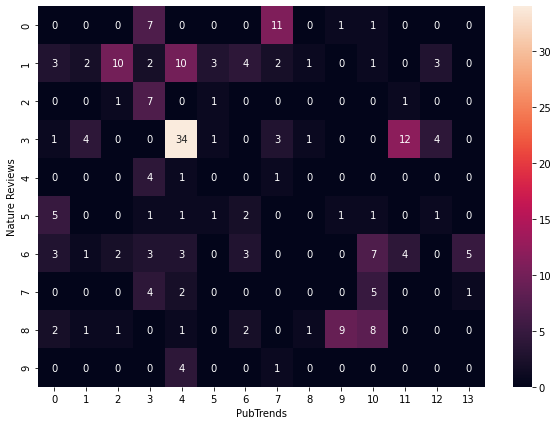

In [140]:
cm = contingency_matrix(labels_true, labels_pred)
plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True)
plt.xlabel('PubTrends')
plt.ylabel('Nature Reviews')

In [96]:
counts, vectorizer = vectorize(full_corpus, n_words=None)

In [100]:
tfidf = compute_tfidf(counts)

In [98]:
dictionary = vectorizer.get_feature_names()

In [145]:
useful_words = sorted(list(map(lambda x: (dictionary[x], tfidf[15, x]), list(tfidf[15, :].indices))),
                      key=lambda el: el[1],
                      reverse=True)

In [146]:
useful_words

[('brain', 0.2859762689423551),
 ('physiology', 0.27719828459102475),
 ('cortex', 0.24770652247378205),
 ('task', 0.19177330500657144),
 ('connection', 0.1856023818256669),
 ('fmri', 0.18463083502970276),
 ('attention', 0.17380053465086545),
 ('active', 0.17094104706102975),
 ('magnetic', 0.1694630442756089),
 ('resonance', 0.16281743469617327),
 ('cognition', 0.16090731991415436),
 ('visual', 0.14857684274023975),
 ('neuron', 0.13915727172726838),
 ('eeg', 0.12996360454604775),
 ('motor', 0.12559134382199375),
 ('performance', 0.12399844856261019),
 ('neural', 0.1230477216686369),
 ('neurofeedback', 0.12274490205763491),
 ('network', 0.12240032549830678),
 ('function', 0.1212653329399748),
 ('computer', 0.11914628603131047),
 ('correlate', 0.10933446096731002),
 ('adhd', 0.10897911864930203),
 ('area', 0.10071399488629502),
 ('cortical', 0.09831734062745837),
 ('human', 0.09765349820279044),
 ('method', 0.09249165087420447),
 ('subject', 0.092113133217939),
 ('reward', 0.0917996889253

In [115]:
useful_words_list = [el[0] for el in useful_words[:200]]

In [97]:
[len(s) for s in full_corpus]

[368497,
 407971,
 321656,
 310549,
 332356,
 347766,
 359825,
 350134,
 322273,
 320773,
 339649,
 321395,
 358586,
 329775,
 294227,
 322995,
 341157,
 348756,
 398028,
 356913,
 355337,
 313663,
 316541,
 343895,
 303870,
 340920,
 303395,
 326029,
 329800,
 358271,
 327305,
 386203,
 363059,
 363864,
 339273,
 368238,
 360409,
 297846,
 335433,
 347745]